# HiP-AD Gradient Conflict Analysis (3-Layer Stage2)

체크포인트별로 task loss를 개별 backward하여 shared 파라미터에서의 gradient conflict를 분석한다.

- **모델**: 3-layer decoder (stage2_3layer, 18ep 학습)
- **체크포인트**: iter_2637 (ep3), iter_5274 (ep6), iter_7911 (ep9), iter_10548 (ep12), iter_13185 (ep15), iter_15822 (ep18)
- **배치**: 12 batches × 8 samples = 96 samples
- **분석**: task pair 간 cosine similarity, magnitude, conflict ratio

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'  # 반드시 torch import 전에 설정

import sys
import json
import logging
from collections import defaultdict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import mmcv
from mmcv import Config
from mmcv.parallel import MMDataParallel
from mmcv.runner import load_checkpoint, wrap_fp16_model

from mmdet.datasets import build_dataset
from mmdet.datasets import build_dataloader as build_dataloader_origin
from mmdet.models import build_detector

os.chdir('/home/kyungmin/min_ws/rideflux/HiP-AD')
import projects.mmdet3d_plugin

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f'Using GPU: {torch.cuda.get_device_name(0)}')

/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Use flash_attn_varlen_kvpacked_func
Using GPU: NVIDIA GeForce RTX 4090


## 1. Config & Settings

In [2]:
CONFIG_PATH = 'projects/configs/hipad_nusc_stage2_3layer.py'
CKPT_DIR = '/data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer'
CKPT_NAMES = ['iter_2637', 'iter_5274', 'iter_7911', 'iter_10548', 'iter_13185', 'iter_15822']
EPOCH_LABELS = ['ep3', 'ep6', 'ep9', 'ep12', 'ep15', 'ep18']  # for display
CKPT_PATHS = [os.path.join(CKPT_DIR, f'{name}.pth') for name in CKPT_NAMES]

NUM_BATCHES = 12   # 12 batches x 8 samples = 96 samples

device = torch.device('cuda:0')  # CUDA_VISIBLE_DEVICES=2 이므로 물리 GPU 2번
torch.cuda.set_device(device)

for p in CKPT_PATHS:
    assert os.path.exists(p), f'{p} not found'
print('All checkpoints found.')

All checkpoints found.


## 2. Task Loss Grouping & Shared Parameter Definition

In [3]:
TASK_PREFIXES = {
    'det': 'det_loss',
    'map': 'map_loss',
    'ego': 'ego_loss',
    'plan': 'plan_loss',
    'motion': 'motion_loss',
}

# 3-layer decoder: 1 single_frame + 2 temporal_frame
num_decoder = 3
num_single_frame_decoder = 1

single_frame_layer = [
    'concat', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
]
temporal_frame_layer = [
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
]

operation_order = (
    single_frame_layer * num_single_frame_decoder +
    temporal_frame_layer * (num_decoder - num_single_frame_decoder)
)

ffn_indices = [i for i, op in enumerate(operation_order) if op == 'ffn']
norm_indices = [i for i, op in enumerate(operation_order) if op == 'norm']
inter_gnn_indices = [i for i, op in enumerate(operation_order) if op == 'inter_gnn']
temp_gnn_indices = [i for i, op in enumerate(operation_order) if op == 'temp_gnn']
gnn_indices = [i for i, op in enumerate(operation_order) if op == 'gnn']

print(f'Total ops: {len(operation_order)}')
print(f'FFN layers:       {ffn_indices}')
print(f'Norm layers:      {norm_indices}')
print(f'Inter_gnn layers: {inter_gnn_indices}')
print(f'Temp_gnn layers:  {temp_gnn_indices}')
print(f'GNN layers:       {gnn_indices}')

PARAM_GROUPS = {
    'backbone': ['img_backbone.', 'img_neck.'],
    'decoder_ffn': [f'.layers.{i}.' for i in ffn_indices],
    'decoder_norm': [f'.layers.{i}.' for i in norm_indices],
    'inter_gnn': [f'.layers.{i}.' for i in inter_gnn_indices],
    'temp_gnn': [f'.layers.{i}.' for i in temp_gnn_indices],
    'gnn': [f'.layers.{i}.' for i in gnn_indices],
    'decouple_fc': ['fc_before.', 'fc_after.'],
}


def group_losses_by_task(loss_dict):
    task_losses = {}
    for task_name, prefix in TASK_PREFIXES.items():
        items = [
            v for k, v in loss_dict.items()
            if k.startswith(prefix) and isinstance(v, torch.Tensor) and v.requires_grad
        ]
        if items:
            task_losses[task_name] = sum(items)
    return task_losses


def classify_param(name):
    groups = []
    for group_name, patterns in PARAM_GROUPS.items():
        if any(p in name for p in patterns):
            groups.append(group_name)
    return groups if groups else None


def get_shared_param_names(model):
    shared = defaultdict(list)
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        groups = classify_param(name)
        if groups:
            for g in groups:
                shared[g].append(name)
    all_names = set()
    for names in shared.values():
        all_names.update(names)
    shared['all_shared'] = sorted(all_names)
    print('Shared parameter groups:')
    for g, names in sorted(shared.items()):
        total = sum(p.numel() for n, p in model.named_parameters() if n in names)
        print(f'  {g}: {len(names)} params, {total:,} elements')
    return dict(shared)

Total ops: 35
FFN layers:       [7, 19, 31]
Norm layers:      [3, 8, 15, 20, 27, 32]
Inter_gnn layers: [2, 14, 26]
Temp_gnn layers:  [12, 24]
GNN layers:       [1, 13, 25]


## 3. Gradient Collection & Metrics

In [4]:
def collect_task_gradients(model, loss_dict):
    task_losses = group_losses_by_task(loss_dict)
    task_grads = {}
    task_names = list(task_losses.keys())
    for i, task_name in enumerate(task_names):
        model.zero_grad()
        retain = (i < len(task_names) - 1)
        task_losses[task_name].backward(retain_graph=retain)
        grads = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                grads[name] = param.grad.clone().float()
        task_grads[task_name] = grads
    loss_values = {k: v.item() for k, v in task_losses.items()}
    return task_grads, loss_values


def flatten_grads(grad_dict, param_names, model):
    """param_names에 해당하는 gradient를 1D vector로. 없는 파라미터는 0으로 채움."""
    vecs = []
    for n in param_names:
        if n in grad_dict:
            vecs.append(grad_dict[n].reshape(-1))
        else:
            # gradient가 없으면 해당 파라미터 shape만큼 0
            param = dict(model.named_parameters())[n]
            vecs.append(torch.zeros(param.numel(), device=param.device))
    return torch.cat(vecs) if vecs else None


def compute_pairwise_metrics(task_grads, param_names, model):
    flat = {}
    for task, gd in task_grads.items():
        f = flatten_grads(gd, param_names, model)
        if f is not None:
            flat[task] = f
    results = {}
    tasks = sorted(flat.keys())
    for i, t1 in enumerate(tasks):
        for t2 in tasks[i+1:]:
            g1, g2 = flat[t1], flat[t2]
            cos = F.cosine_similarity(g1.unsqueeze(0), g2.unsqueeze(0)).item()
            results[(t1, t2)] = {
                'cosine': cos,
                'mag_t1': g1.norm().item(),
                'mag_t2': g2.norm().item(),
            }
    return results

## 4. Build Dataset (train pipeline, augmentation off)

In [5]:
cfg = Config.fromfile(CONFIG_PATH)
cfg.model.pretrained = None

train_cfg = cfg.data.train.copy()
train_cfg.data_aug_conf = dict(
    resize_lim=(0.44, 0.44),
    final_dim=tuple(cfg.input_shape[::-1]),
    bot_pct_lim=(0.0, 0.0),
    rot_lim=(0.0, 0.0),
    H=900, W=1600,
    rand_flip=False,
    rot3d_range=[0, 0],
)

dataset = build_dataset(train_cfg)
print(f'Dataset size: {len(dataset)}')

data_loader = build_dataloader_origin(
    dataset,
    samples_per_gpu=cfg.data.samples_per_gpu,
    workers_per_gpu=2,
    dist=False,
    shuffle=False,
)
print(f'Batch size: {cfg.data.samples_per_gpu}, Num batches: {NUM_BATCHES}')

{'version': 'v1.0-trainval'}
Dataset size: 28130
Batch size: 8, Num batches: 12


## 5. Run Analysis per Checkpoint

In [6]:
def analyze_one_checkpoint(ckpt_path, data_loader, cfg, num_batches):
    mmcv_logger = logging.getLogger('mmcv')
    prev_level = mmcv_logger.level
    mmcv_logger.setLevel(logging.WARNING)

    model = build_detector(cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
    model.init_weights()
    fp16_cfg = cfg.get('fp16', None)
    if fp16_cfg is not None:
        wrap_fp16_model(model)
    load_checkpoint(model, ckpt_path, map_location='cpu')
    mmcv_logger.setLevel(prev_level)

    model = MMDataParallel(model.cuda(), device_ids=[0])
    model.train()

    raw_model = model.module
    shared_params = get_shared_param_names(raw_model)

    batch_results = []
    batch_losses = []

    for batch_idx, data in enumerate(data_loader):
        if batch_idx >= num_batches:
            break
        print(f'  batch {batch_idx+1}/{num_batches}', end=' ', flush=True)
        try:
            loss_dict = model(return_loss=True, **data)
        except Exception as e:
            print(f'FAILED: {e}')
            continue

        task_grads, loss_vals = collect_task_gradients(raw_model, loss_dict)
        batch_losses.append(loss_vals)

        metrics_per_group = {}
        for group_name, param_names in shared_params.items():
            metrics_per_group[group_name] = compute_pairwise_metrics(task_grads, param_names, raw_model)
        batch_results.append(metrics_per_group)

        total = sum(loss_vals.values())
        print(f'total_loss={total:.4f}')

        del task_grads, loss_dict
        torch.cuda.empty_cache()

    del model
    torch.cuda.empty_cache()
    return batch_results, batch_losses, shared_params

In [7]:
all_results = {}
all_losses = {}
shared_params = None

for ckpt_name, epoch_label, ckpt_path in zip(CKPT_NAMES, EPOCH_LABELS, CKPT_PATHS):
    display_name = f'{ckpt_name} ({epoch_label})'
    print(f'\n{"="*50}')
    print(f'Checkpoint: {display_name}')
    print(f'{"="*50}')

    dl = build_dataloader_origin(
        dataset,
        samples_per_gpu=cfg.data.samples_per_gpu,
        workers_per_gpu=2,
        dist=False,
        shuffle=False,
    )

    batch_results, batch_losses, shared_params = analyze_one_checkpoint(
        ckpt_path, dl, cfg, NUM_BATCHES
    )
    all_results[epoch_label] = batch_results
    all_losses[epoch_label] = batch_losses

print('\nDone!')


Checkpoint: iter_2637 (ep3)


/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '
2026-04-04 21:16:05,134 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias



load checkpoint from local path: /data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer/iter_2637.pth
Shared parameter groups:
  all_shared: 301 params, 27,524,416 elements
  backbone: 179 params, 24,590,912 elements
  decoder_ffn: 36 params, 791,040 elements
  decoder_norm: 12 params, 1,536 elements
  decouple_fc: 2 params, 65,536 elements
  gnn: 30 params, 1,184,640 elements
  inter_gnn: 24 params, 297,216 elements
  temp_gnn: 24 params, 790,528 elements
  batch 1/12 total_loss=17.7189
  batch 2/12 total_loss=16.4579
  batch 3/12 total_loss=15.2694
  batch 4/12 total_loss=14.0233
  batch 5/12 total_loss=13.1889
  batch 6/12 total_loss=22.6891
  batch 7/12 total_loss=18.4752
  batch 8/12 total_loss=14.0276
  batch 9/12 total_loss=14.8957
  batch 10/12 total_loss=12.7507
  batch 11/12 total_loss=13.7146
  batch 12/12 total_loss=13.1773

Checkpoint: iter_5274 (ep6)


2026-04-04 21:16:52,151 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias



load checkpoint from local path: /data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer/iter_5274.pth
Shared parameter groups:
  all_shared: 301 params, 27,524,416 elements
  backbone: 179 params, 24,590,912 elements
  decoder_ffn: 36 params, 791,040 elements
  decoder_norm: 12 params, 1,536 elements
  decouple_fc: 2 params, 65,536 elements
  gnn: 30 params, 1,184,640 elements
  inter_gnn: 24 params, 297,216 elements
  temp_gnn: 24 params, 790,528 elements
  batch 1/12 total_loss=15.7780
  batch 2/12 total_loss=16.3341
  batch 3/12 total_loss=15.2018
  batch 4/12 total_loss=13.8720
  batch 5/12 total_loss=12.7493
  batch 6/12 total_loss=21.7690
  batch 7/12 total_loss=18.4129
  batch 8/12 total_loss=13.6242
  batch 9/12 total_loss=15.1087
  batch 10/12 total_loss=11.8733
  batch 11/12 total_loss=13.1727
  batch 12/12 total_loss=12.0820

Checkpoint: iter_7911 (ep9)


...

load checkpoint from local path: /data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer/iter_10548.pth
Shared parameter groups:
  all_shared: 301 params, 27,524,416 elements
  backbone: 179 params, 24,590,912 elements
  decoder_ffn: 36 params, 791,040 elements
  decoder_norm: 12 params, 1,536 elements
  decouple_fc: 2 params, 65,536 elements
  gnn: 30 params, 1,184,640 elements
  inter_gnn: 24 params, 297,216 elements
  temp_gnn: 24 params, 790,528 elements
  batch 1/12 total_loss=14.9864
  batch 2/12 total_loss=15.4368
  batch 3/12 total_loss=14.1859
  batch 4/12 total_loss=14.0364
  batch 5/12 total_loss=12.9355
  batch 6/12 total_loss=20.9035
  batch 7/12 total_loss=16.6262
  batch 8/12 total_loss=13.3013
  batch 9/12 total_loss=14.0078
  batch 10/12 total_loss=11.6228
  batch 11/12 total_loss=11.9557
  batch 12/12 total_loss=12.5610

Checkpoint: iter_13185 (ep15)


2026-04-04 21:19:01,502 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias



load checkpoint from local path: /data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer/iter_13185.pth
Shared parameter groups:
  all_shared: 301 params, 27,524,416 elements
  backbone: 179 params, 24,590,912 elements
  decoder_ffn: 36 params, 791,040 elements
  decoder_norm: 12 params, 1,536 elements
  decouple_fc: 2 params, 65,536 elements
  gnn: 30 params, 1,184,640 elements
  inter_gnn: 24 params, 297,216 elements
  temp_gnn: 24 params, 790,528 elements
  batch 1/12 total_loss=13.7801
  batch 2/12 total_loss=14.9362
  batch 3/12 total_loss=13.8451
  batch 4/12 total_loss=13.9434
  batch 5/12 total_loss=12.4423
  batch 6/12 total_loss=21.0699
  batch 7/12 total_loss=16.5191
  batch 8/12 total_loss=13.7447
  batch 9/12 total_loss=13.5756
  batch 10/12 total_loss=11.7370
  batch 11/12 total_loss=11.8380
  batch 12/12 total_loss=11.6662

Checkpoint: iter_15822 (ep18)


2026-04-04 21:19:44,319 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias



load checkpoint from local path: /data3/kyungmin/work_dirs/hipad/work_dirs/hipad_nusc_stage2_3layer/iter_15822.pth
Shared parameter groups:
  all_shared: 301 params, 27,524,416 elements
  backbone: 179 params, 24,590,912 elements
  decoder_ffn: 36 params, 791,040 elements
  decoder_norm: 12 params, 1,536 elements
  decouple_fc: 2 params, 65,536 elements
  gnn: 30 params, 1,184,640 elements
  inter_gnn: 24 params, 297,216 elements
  temp_gnn: 24 params, 790,528 elements
  batch 1/12 total_loss=14.7251
  batch 2/12 total_loss=14.3557
  batch 3/12 total_loss=13.7552
  batch 4/12 total_loss=12.9511
  batch 5/12 total_loss=12.1094
  batch 6/12 total_loss=20.6560
  batch 7/12 total_loss=16.1597
  batch 8/12 total_loss=12.4051
  batch 9/12 total_loss=13.8179
  batch 10/12 total_loss=11.6896
  batch 11/12 total_loss=11.6467
  batch 12/12 total_loss=11.4866

Done!


## 6. Aggregate & Summary

In [8]:
def aggregate(batch_results):
    if not batch_results:
        return {}
    agg = {}
    for group_name in batch_results[0].keys():
        pair_data = defaultdict(lambda: defaultdict(list))
        for br in batch_results:
            for pair, metrics in br.get(group_name, {}).items():
                for k, v in metrics.items():
                    pair_data[pair][k].append(v)
        group_agg = {}
        for pair, metrics in pair_data.items():
            d = {}
            for k, vals in metrics.items():
                arr = np.array(vals)
                d[f'{k}_mean'] = arr.mean()
                d[f'{k}_std'] = arr.std()
                if k == 'cosine':
                    d['conflict_ratio'] = (arr < 0).mean()
                    d['cosine_all'] = arr
            group_agg[pair] = d
        agg[group_name] = group_agg
    return agg


agg_results = {name: aggregate(br) for name, br in all_results.items()}

for epoch_label in EPOCH_LABELS:
    print(f'\n{"─"*50}')
    print(f'{epoch_label}')
    print(f'{"─"*50}')
    avg_loss = defaultdict(list)
    for bl in all_losses[epoch_label]:
        for task, val in bl.items():
            avg_loss[task].append(val)
    print('Task losses:')
    for task in sorted(avg_loss):
        vals = avg_loss[task]
        print(f'  {task:>10s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}')

    for group in ['decoder_ffn', 'inter_gnn', 'backbone', 'all_shared']:
        if group not in agg_results[epoch_label]:
            continue
        print(f'\n  [{group}]')
        for pair, m in sorted(agg_results[epoch_label][group].items()):
            cos = m['cosine_mean']
            std = m['cosine_std']
            cr = m['conflict_ratio']
            flag = ' << CONFLICT' if cos < -0.05 else ''
            print(f'    {str(pair):>30s}: cos={cos:+.4f}+/-{std:.4f}  CR={cr:.2f}{flag}')


──────────────────────────────────────────────────
ep3
──────────────────────────────────────────────────
Task losses:
         det: 8.1351 +/- 0.3723
         ego: 0.0000 +/- 0.0000
         map: 3.0121 +/- 0.3804
      motion: 3.0834 +/- 2.2139
        plan: 1.3018 +/- 0.6084

  [decoder_ffn]
                    ('det', 'ego'): cos=+0.0000+/-0.0000  CR=0.00
                    ('det', 'map'): cos=+0.0088+/-0.0096  CR=0.33
                 ('det', 'motion'): cos=+0.1299+/-0.1954  CR=0.33
                   ('det', 'plan'): cos=+0.0038+/-0.0388  CR=0.50
                    ('ego', 'map'): cos=+0.0000+/-0.0000  CR=0.00
                 ('ego', 'motion'): cos=+0.0000+/-0.0000  CR=0.00
                   ('ego', 'plan'): cos=+0.0000+/-0.0000  CR=0.00
                 ('map', 'motion'): cos=+0.0013+/-0.0094  CR=0.42
                   ('map', 'plan'): cos=+0.0048+/-0.0252  CR=0.50
                ('motion', 'plan'): cos=+0.0098+/-0.0289  CR=0.50

  [inter_gnn]
                    ('det', 

## 7. Cosine Similarity Heatmaps per Checkpoint

/tmp/ipykernel_3174759/3369076879.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


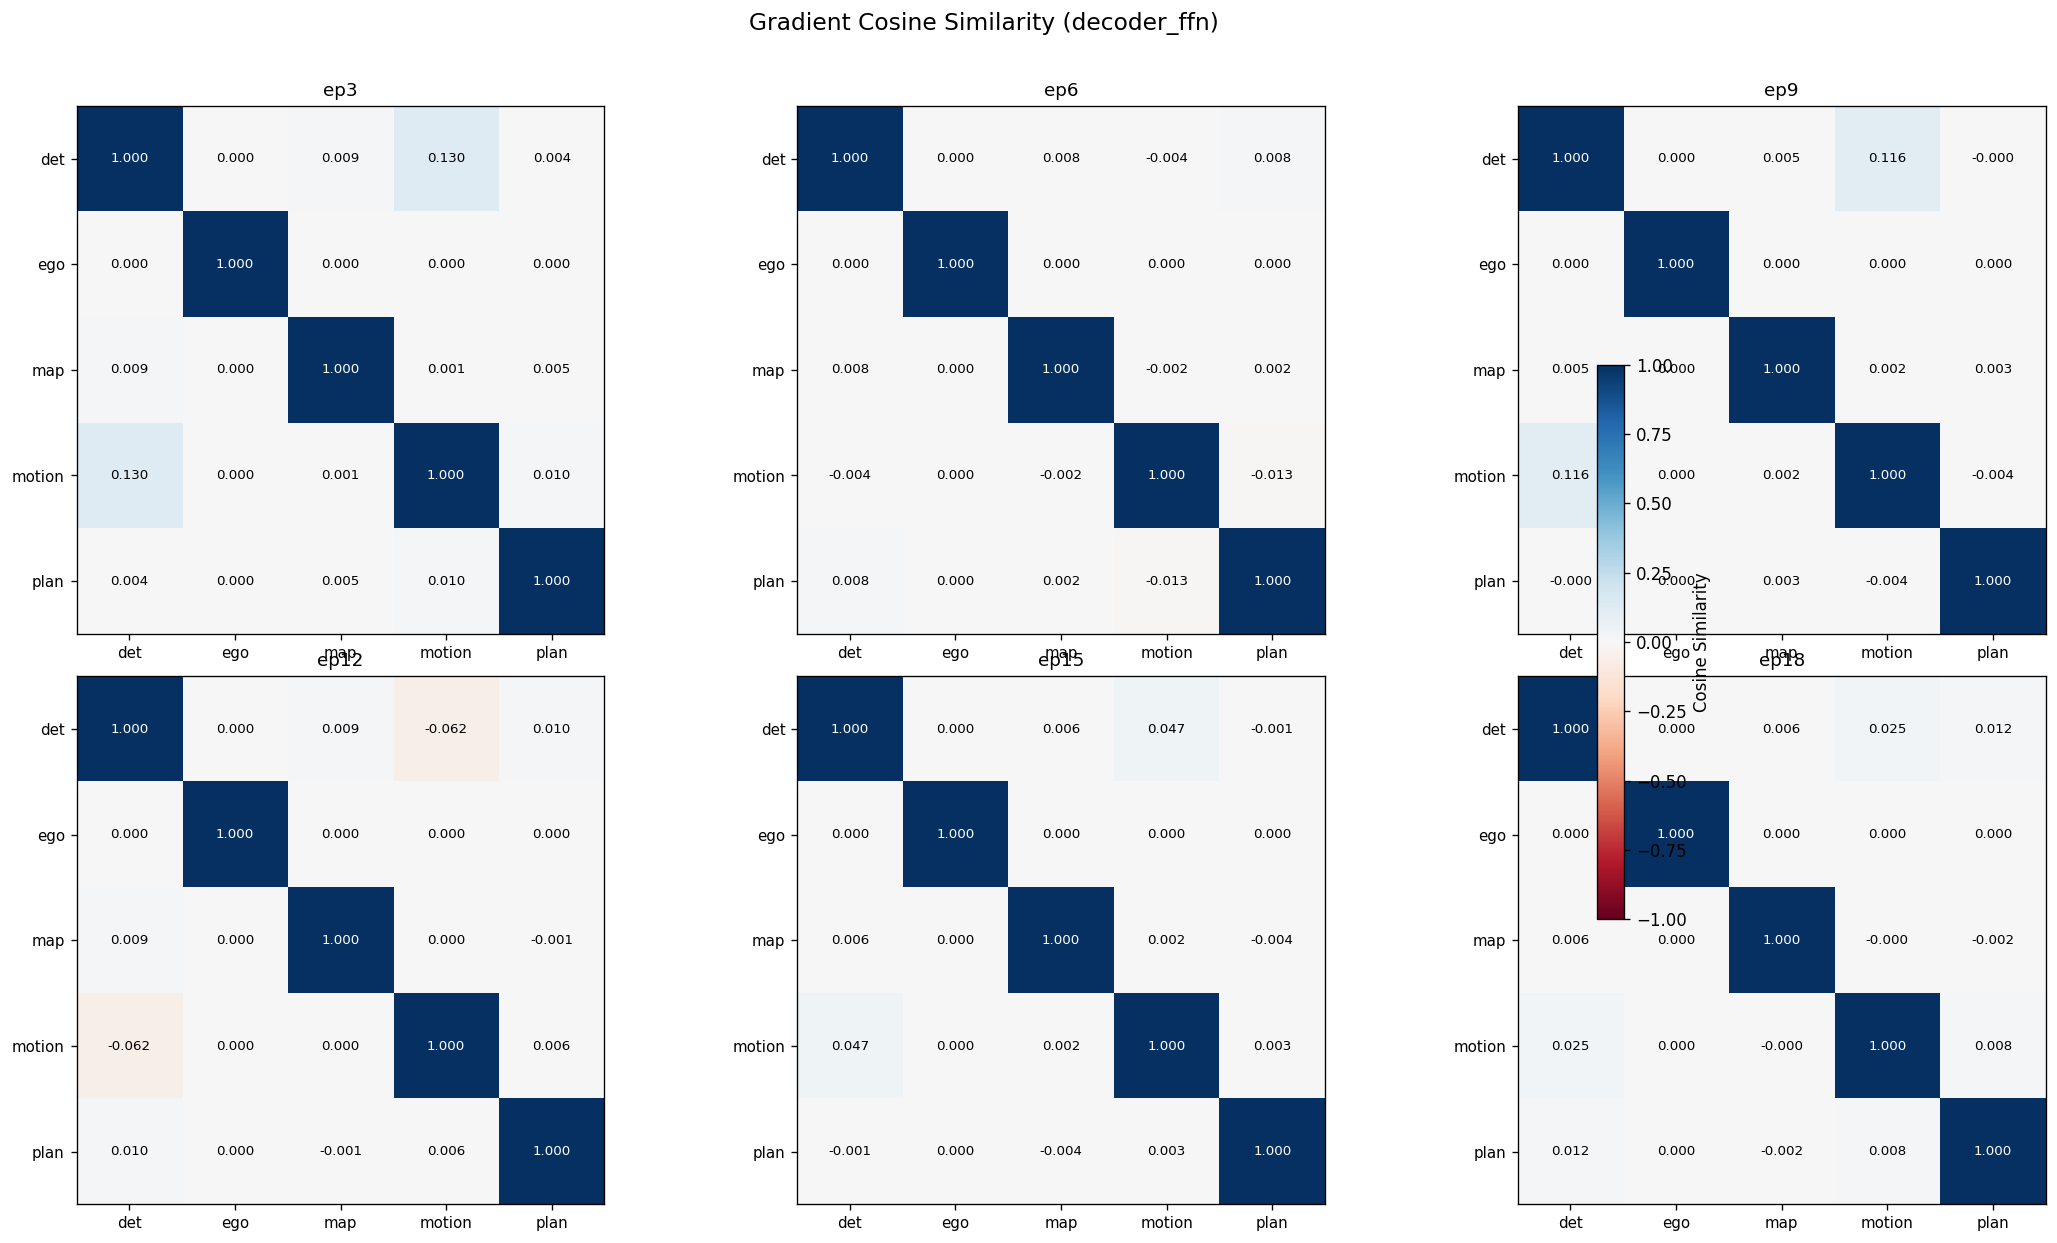

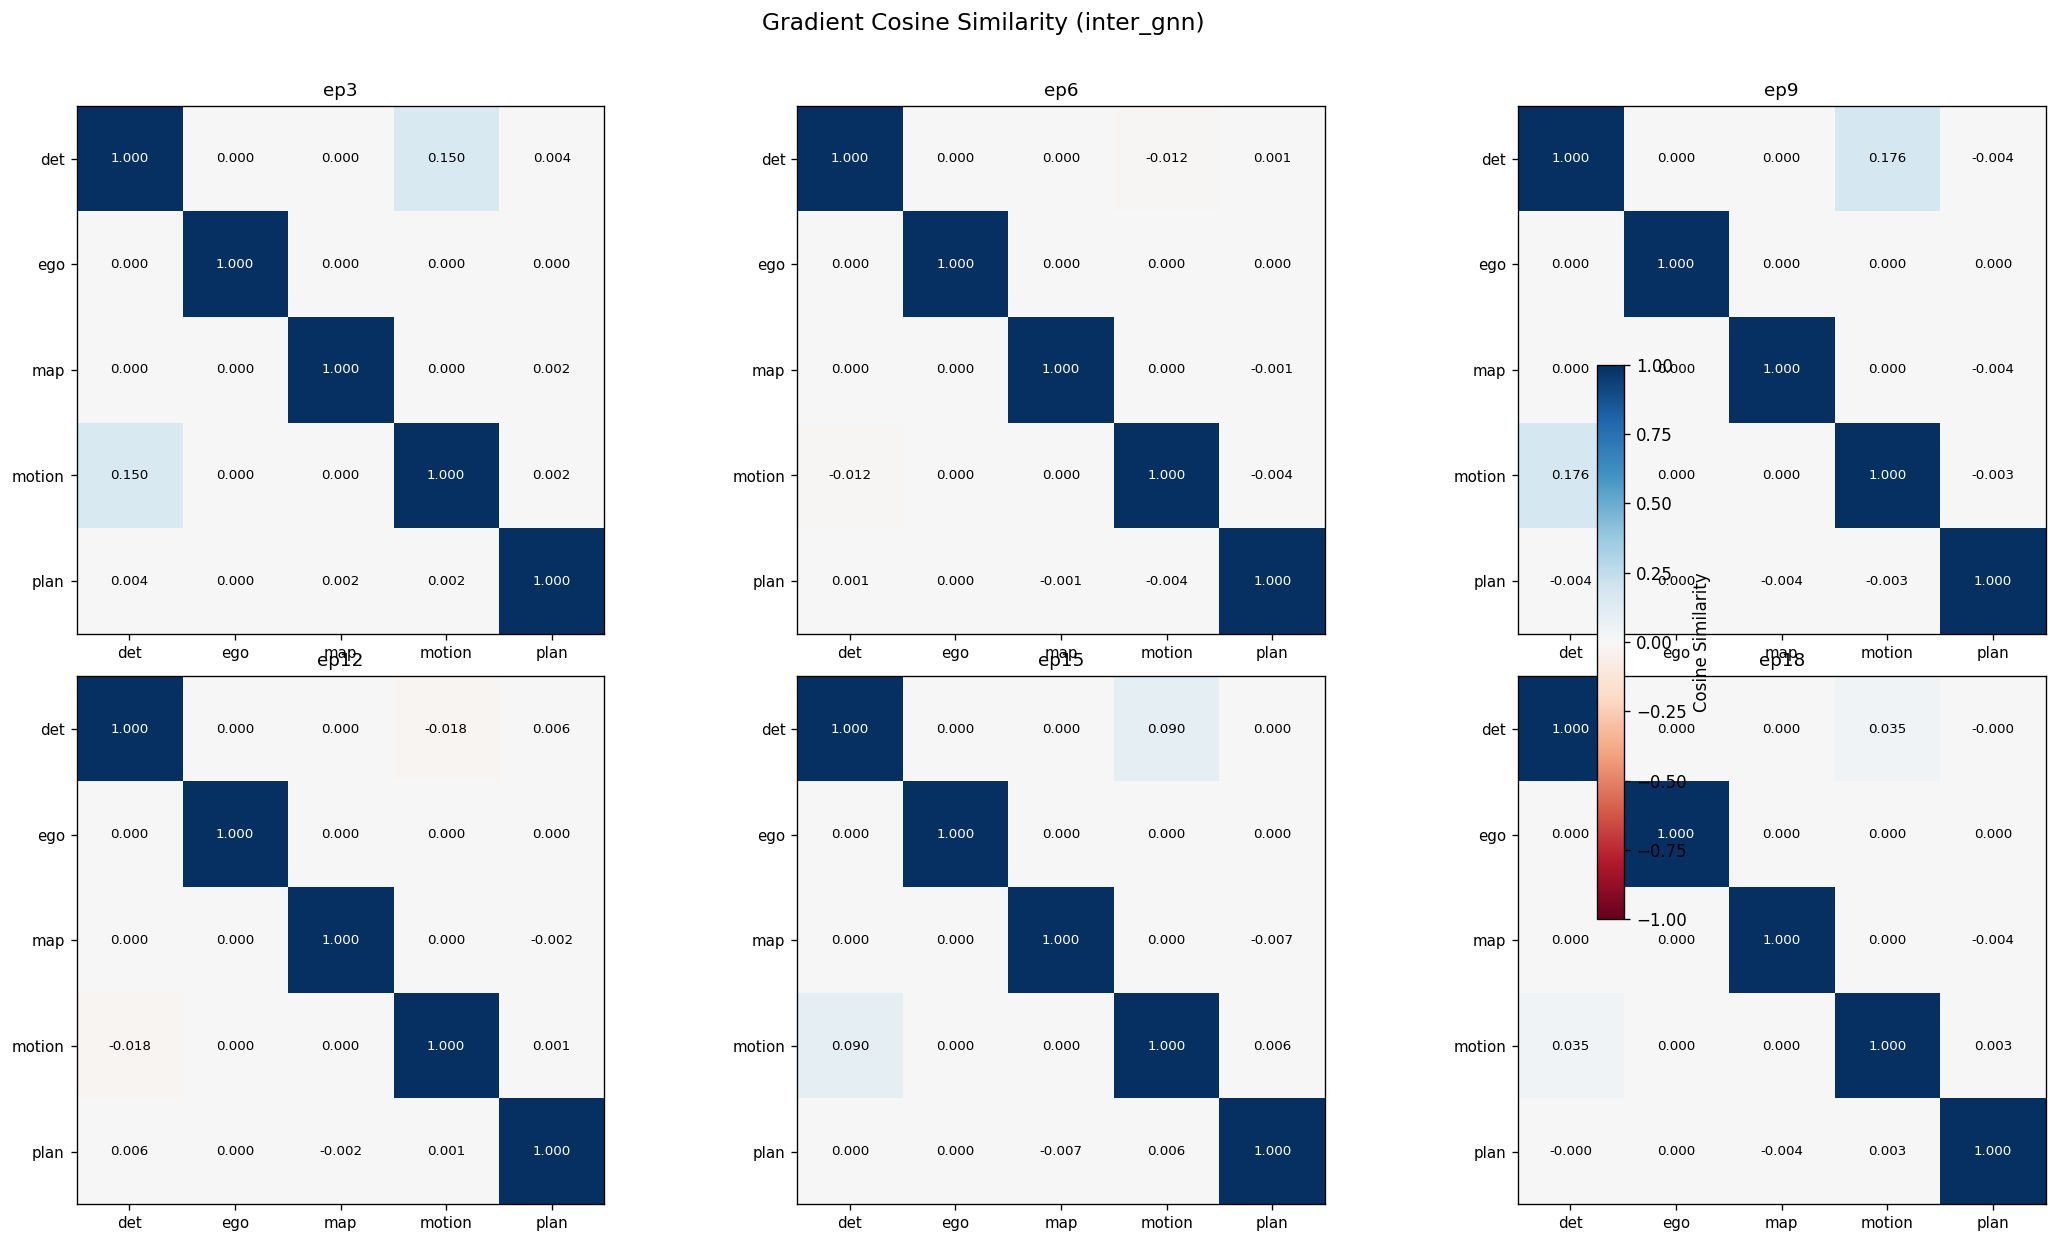

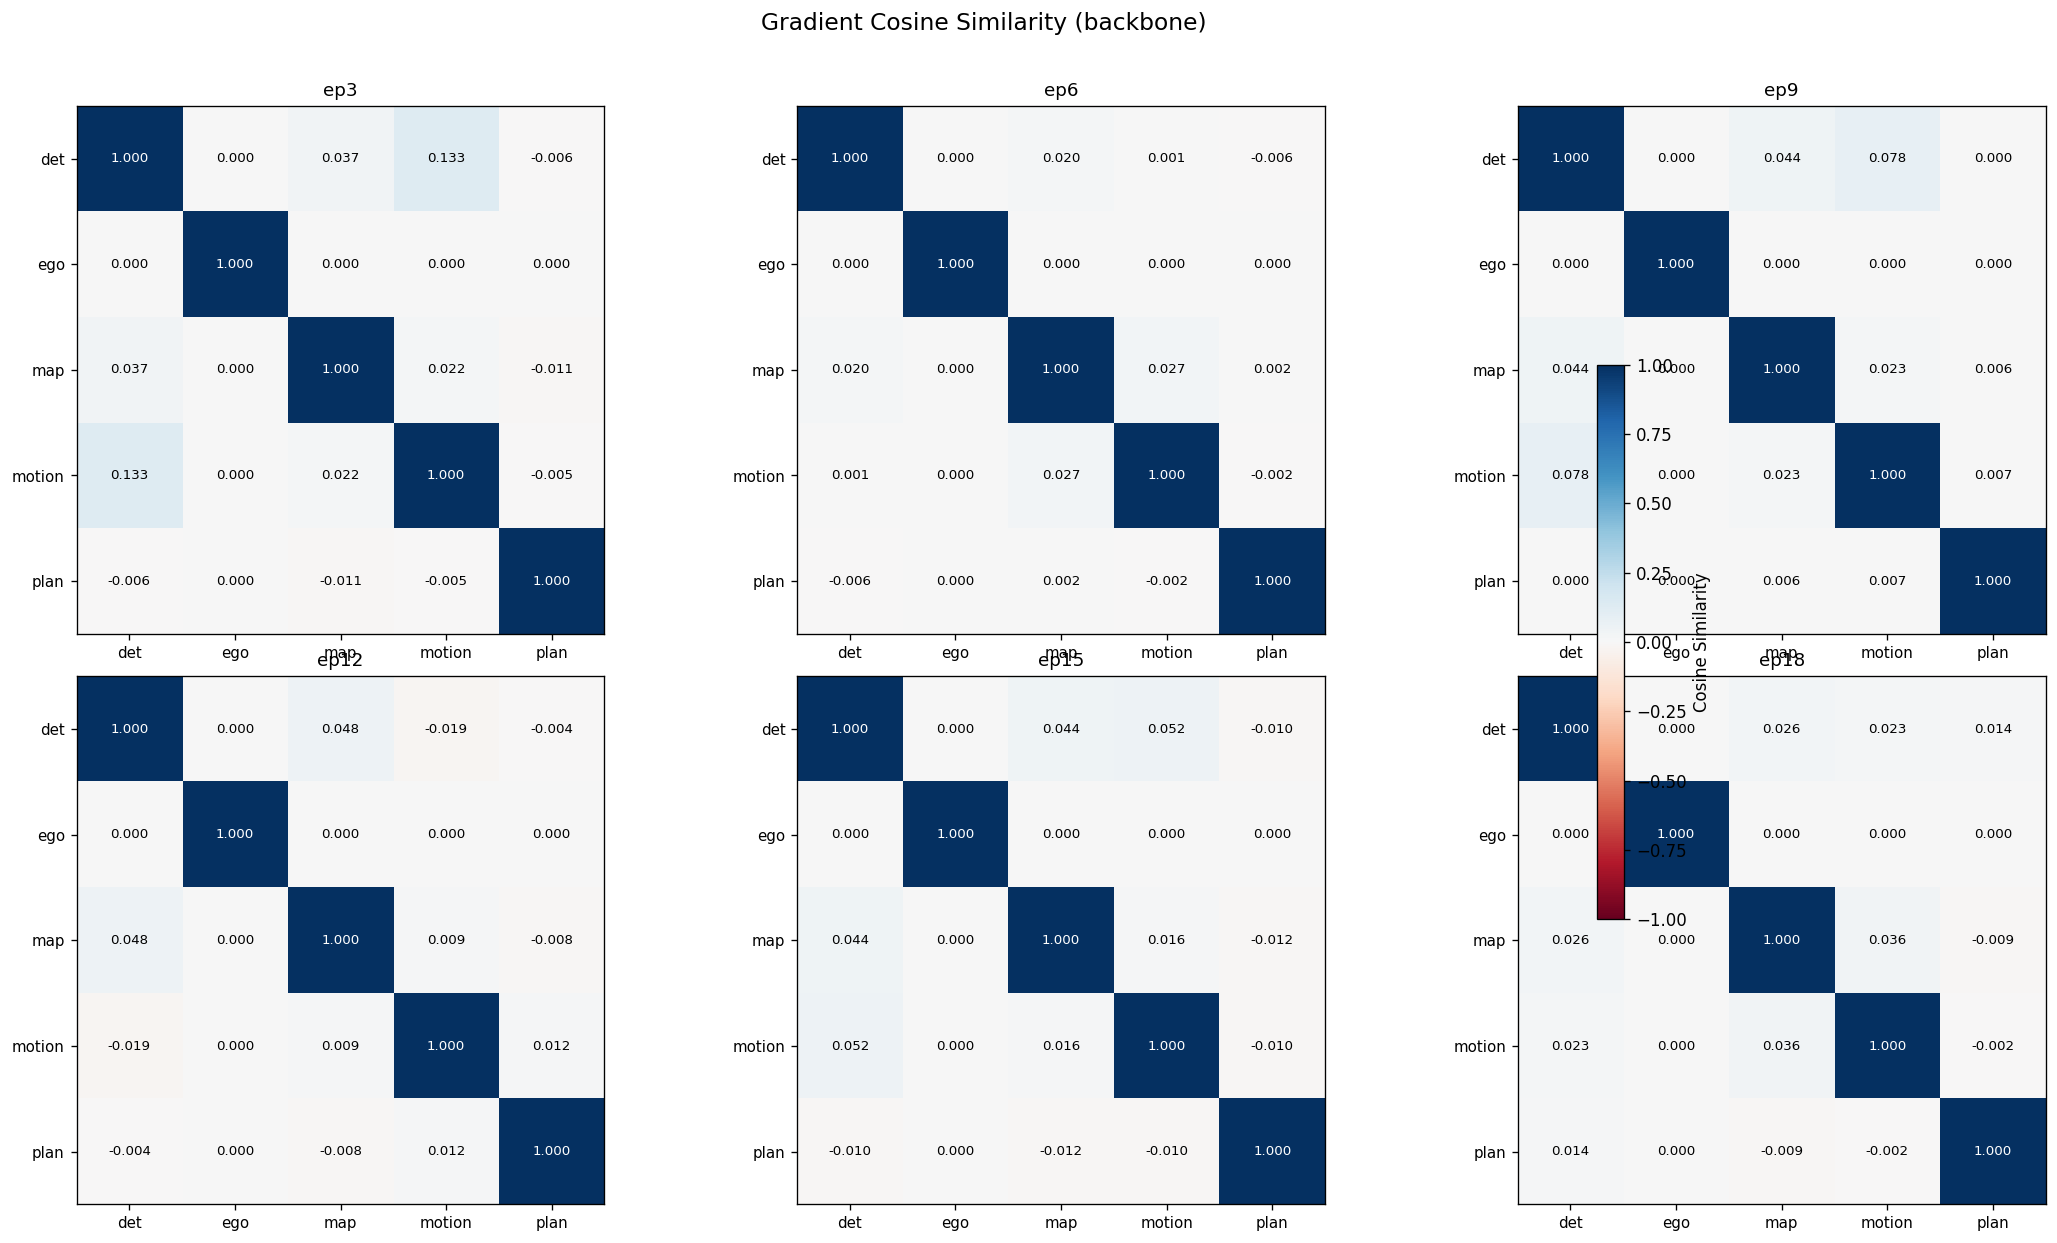

In [9]:
def plot_cosine_heatmaps(agg_results, epoch_labels, group='all_shared'):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, epoch_label in zip(axes, epoch_labels):
        data = agg_results[epoch_label].get(group, {})
        tasks = sorted(set(t for pair in data for t in pair))
        n = len(tasks)
        if n < 2:
            ax.set_title(f'{epoch_label}\n(no data)')
            continue
        matrix = np.eye(n)
        for pair, m in data.items():
            t1, t2 = pair
            i, j = tasks.index(t1), tasks.index(t2)
            val = m['cosine_mean']
            matrix[i][j] = val
            matrix[j][i] = val
        im = ax.imshow(matrix, cmap='RdBu', vmin=-1, vmax=1)
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(tasks, fontsize=9)
        ax.set_yticklabels(tasks, fontsize=9)
        for i in range(n):
            for j in range(n):
                color = 'white' if abs(matrix[i][j]) > 0.5 else 'black'
                ax.text(j, i, f'{matrix[i][j]:.3f}', ha='center', va='center',
                        fontsize=8, color=color)
        ax.set_title(f'{epoch_label}', fontsize=11)
    fig.suptitle(f'Gradient Cosine Similarity ({group})', fontsize=14, y=1.02)
    fig.colorbar(im, ax=axes, shrink=0.6, label='Cosine Similarity')
    plt.tight_layout()
    plt.show()


for g in ['decoder_ffn', 'inter_gnn', 'backbone']:
    plot_cosine_heatmaps(agg_results, EPOCH_LABELS, group=g)

## 8. Cosine Trend across Checkpoints

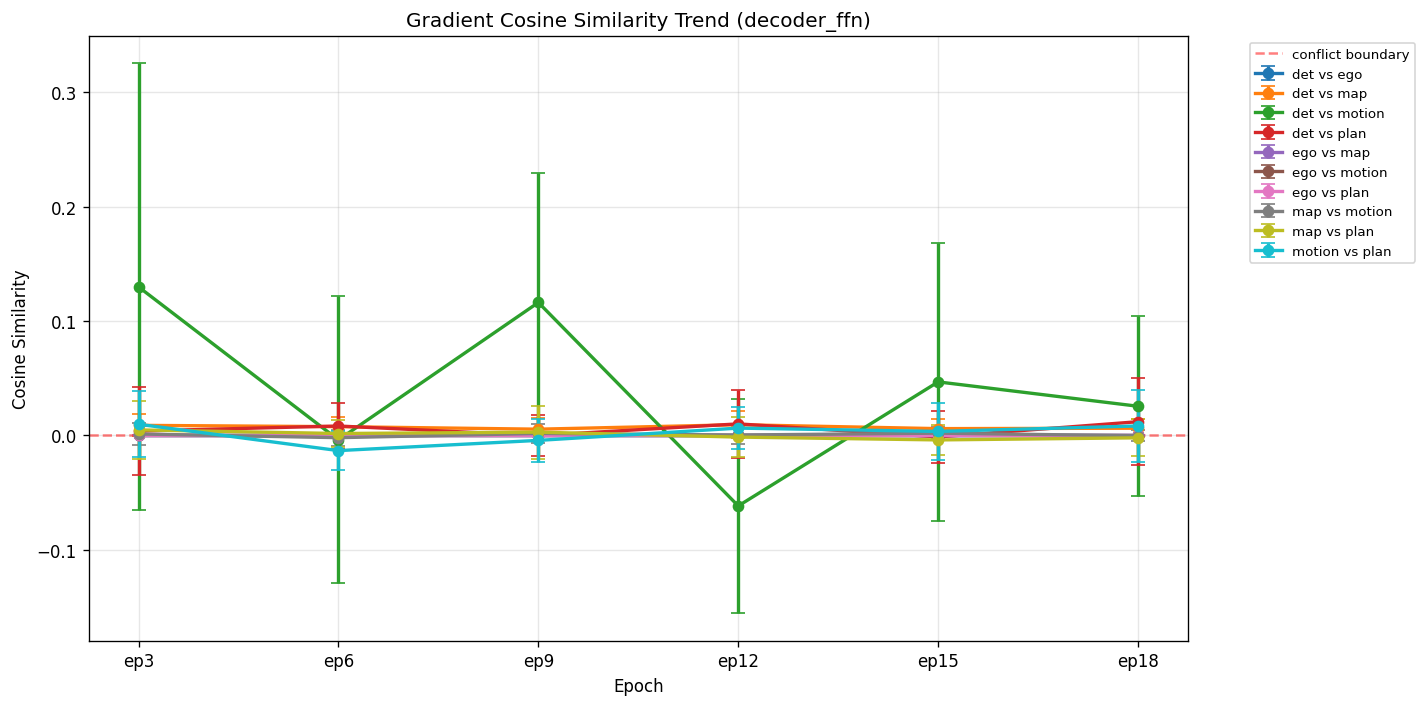

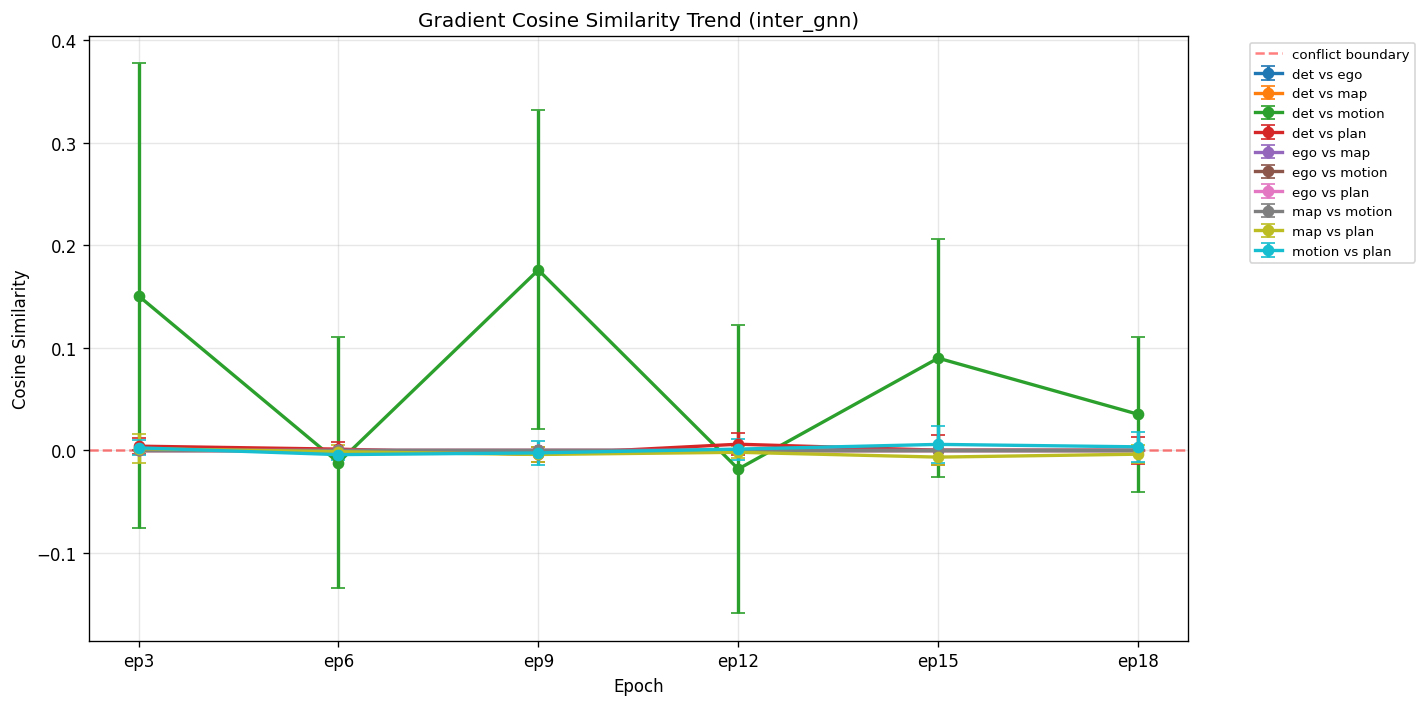

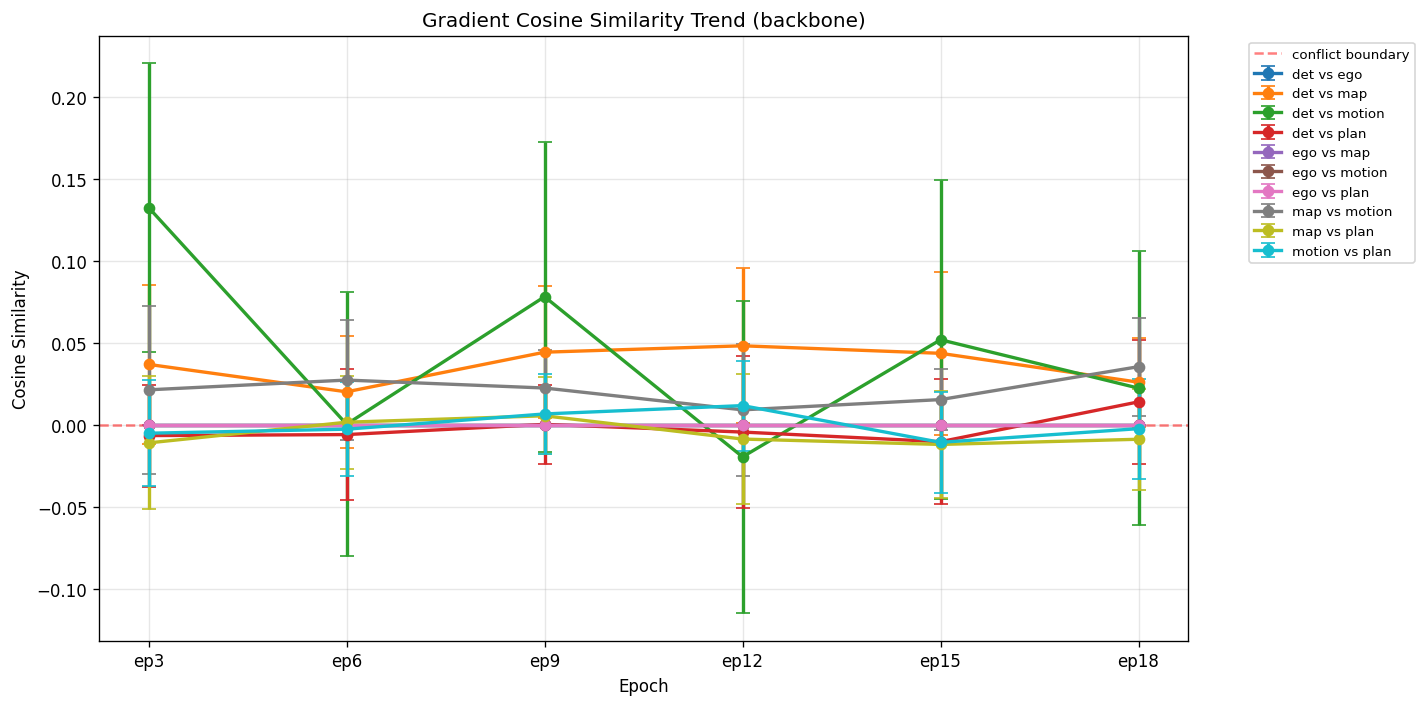

In [10]:
def plot_cosine_trend(agg_results, epoch_labels, group='all_shared'):
    all_pairs = set()
    for name in epoch_labels:
        all_pairs.update(agg_results[name].get(group, {}).keys())
    all_pairs = sorted(all_pairs)
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(epoch_labels))
    for pair in all_pairs:
        means = []
        stds = []
        for name in epoch_labels:
            m = agg_results[name].get(group, {}).get(pair, {})
            means.append(m.get('cosine_mean', np.nan))
            stds.append(m.get('cosine_std', 0))
        label = f'{pair[0]} vs {pair[1]}'
        ax.errorbar(x, means, yerr=stds, marker='o', capsize=4, label=label, linewidth=2)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='conflict boundary')
    ax.set_xticks(x)
    ax.set_xticklabels(epoch_labels)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'Gradient Cosine Similarity Trend ({group})')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for g in ['decoder_ffn', 'inter_gnn', 'backbone']:
    plot_cosine_trend(agg_results, EPOCH_LABELS, group=g)

## 9. Conflict Ratio per Task Pair

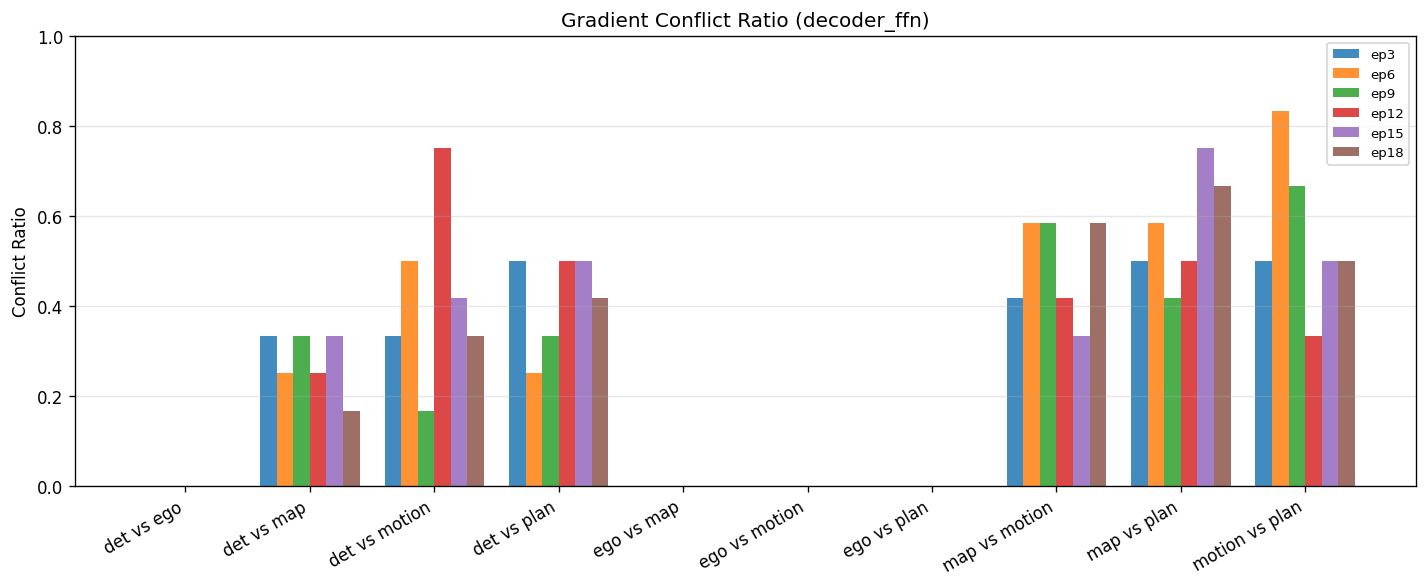

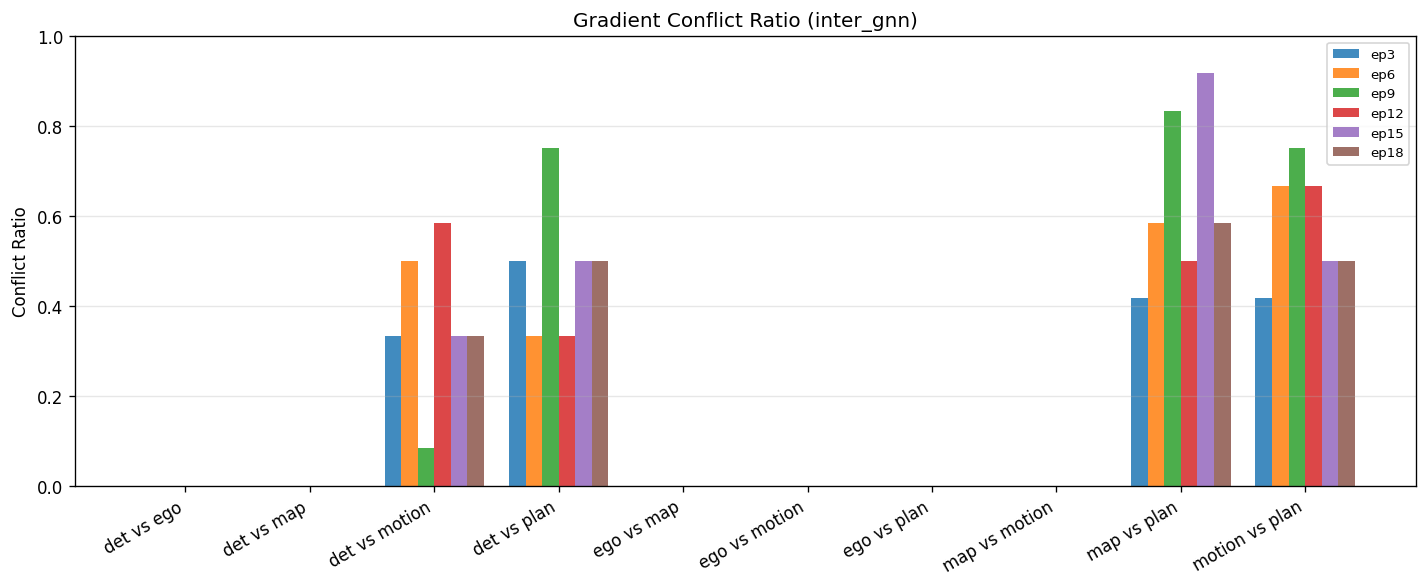

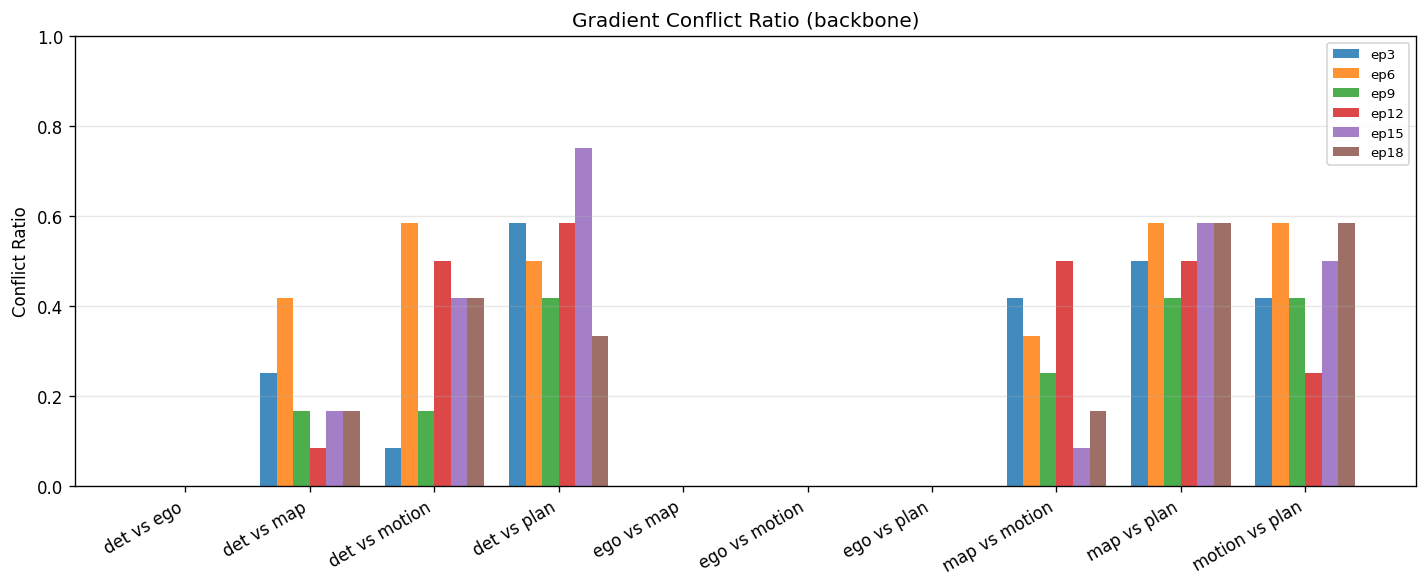

In [11]:
def plot_conflict_ratio(agg_results, epoch_labels, group='all_shared'):
    all_pairs = set()
    for name in epoch_labels:
        all_pairs.update(agg_results[name].get(group, {}).keys())
    all_pairs = sorted(all_pairs)
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(all_pairs))
    width = 0.8 / len(epoch_labels)
    for i, name in enumerate(epoch_labels):
        ratios = []
        for pair in all_pairs:
            m = agg_results[name].get(group, {}).get(pair, {})
            ratios.append(m.get('conflict_ratio', 0))
        ax.bar(x + i * width, ratios, width, label=name, alpha=0.85)
    ax.set_xticks(x + width * (len(epoch_labels) - 1) / 2)
    ax.set_xticklabels([f'{p[0]} vs {p[1]}' for p in all_pairs], rotation=30, ha='right')
    ax.set_ylabel('Conflict Ratio')
    ax.set_ylim(0, 1)
    ax.set_title(f'Gradient Conflict Ratio ({group})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


for g in ['decoder_ffn', 'inter_gnn', 'backbone']:
    plot_conflict_ratio(agg_results, EPOCH_LABELS, group=g)

## 10. Gradient Magnitude per Task

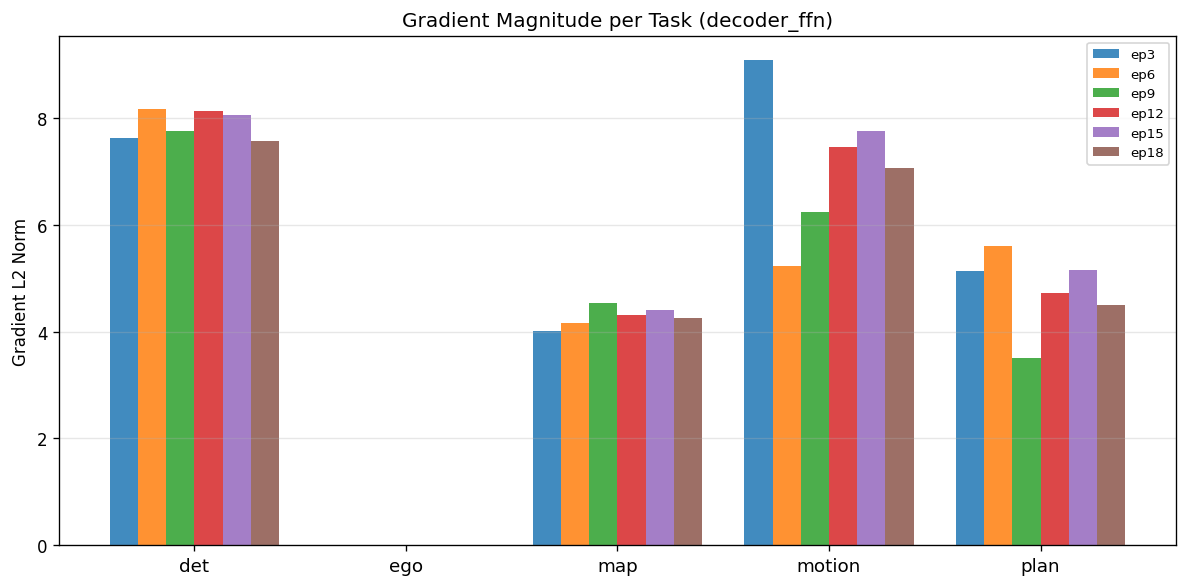

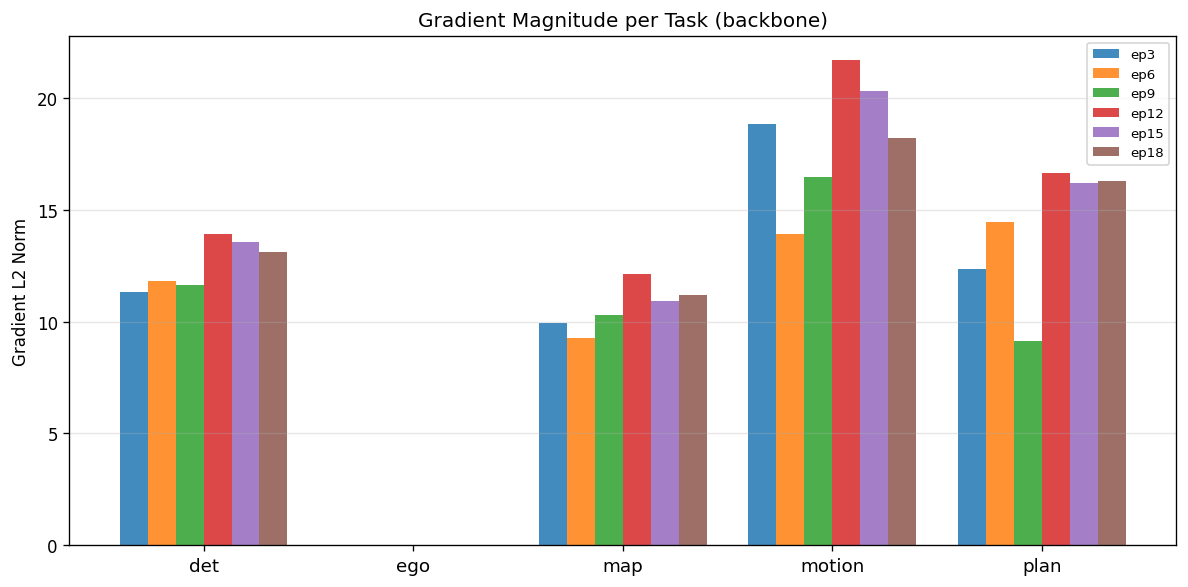

In [12]:
def plot_magnitude(agg_results, epoch_labels, group='all_shared'):
    all_tasks = set()
    for name in epoch_labels:
        for pair in agg_results[name].get(group, {}):
            all_tasks.update(pair)
    all_tasks = sorted(all_tasks)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(all_tasks))
    width = 0.8 / len(epoch_labels)
    for i, epoch_label in enumerate(epoch_labels):
        mags = []
        for task in all_tasks:
            mag_vals = []
            for pair, m in agg_results[epoch_label].get(group, {}).items():
                if pair[0] == task:
                    mag_vals.append(m.get('mag_t1_mean', 0))
                elif pair[1] == task:
                    mag_vals.append(m.get('mag_t2_mean', 0))
            mags.append(np.mean(mag_vals) if mag_vals else 0)
        ax.bar(x + i * width, mags, width, label=epoch_label, alpha=0.85)
    ax.set_xticks(x + width * (len(epoch_labels) - 1) / 2)
    ax.set_xticklabels(all_tasks, fontsize=11)
    ax.set_ylabel('Gradient L2 Norm')
    ax.set_title(f'Gradient Magnitude per Task ({group})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


for g in ['decoder_ffn', 'backbone']:
    plot_magnitude(agg_results, EPOCH_LABELS, group=g)

## 11. Per-group Comparison

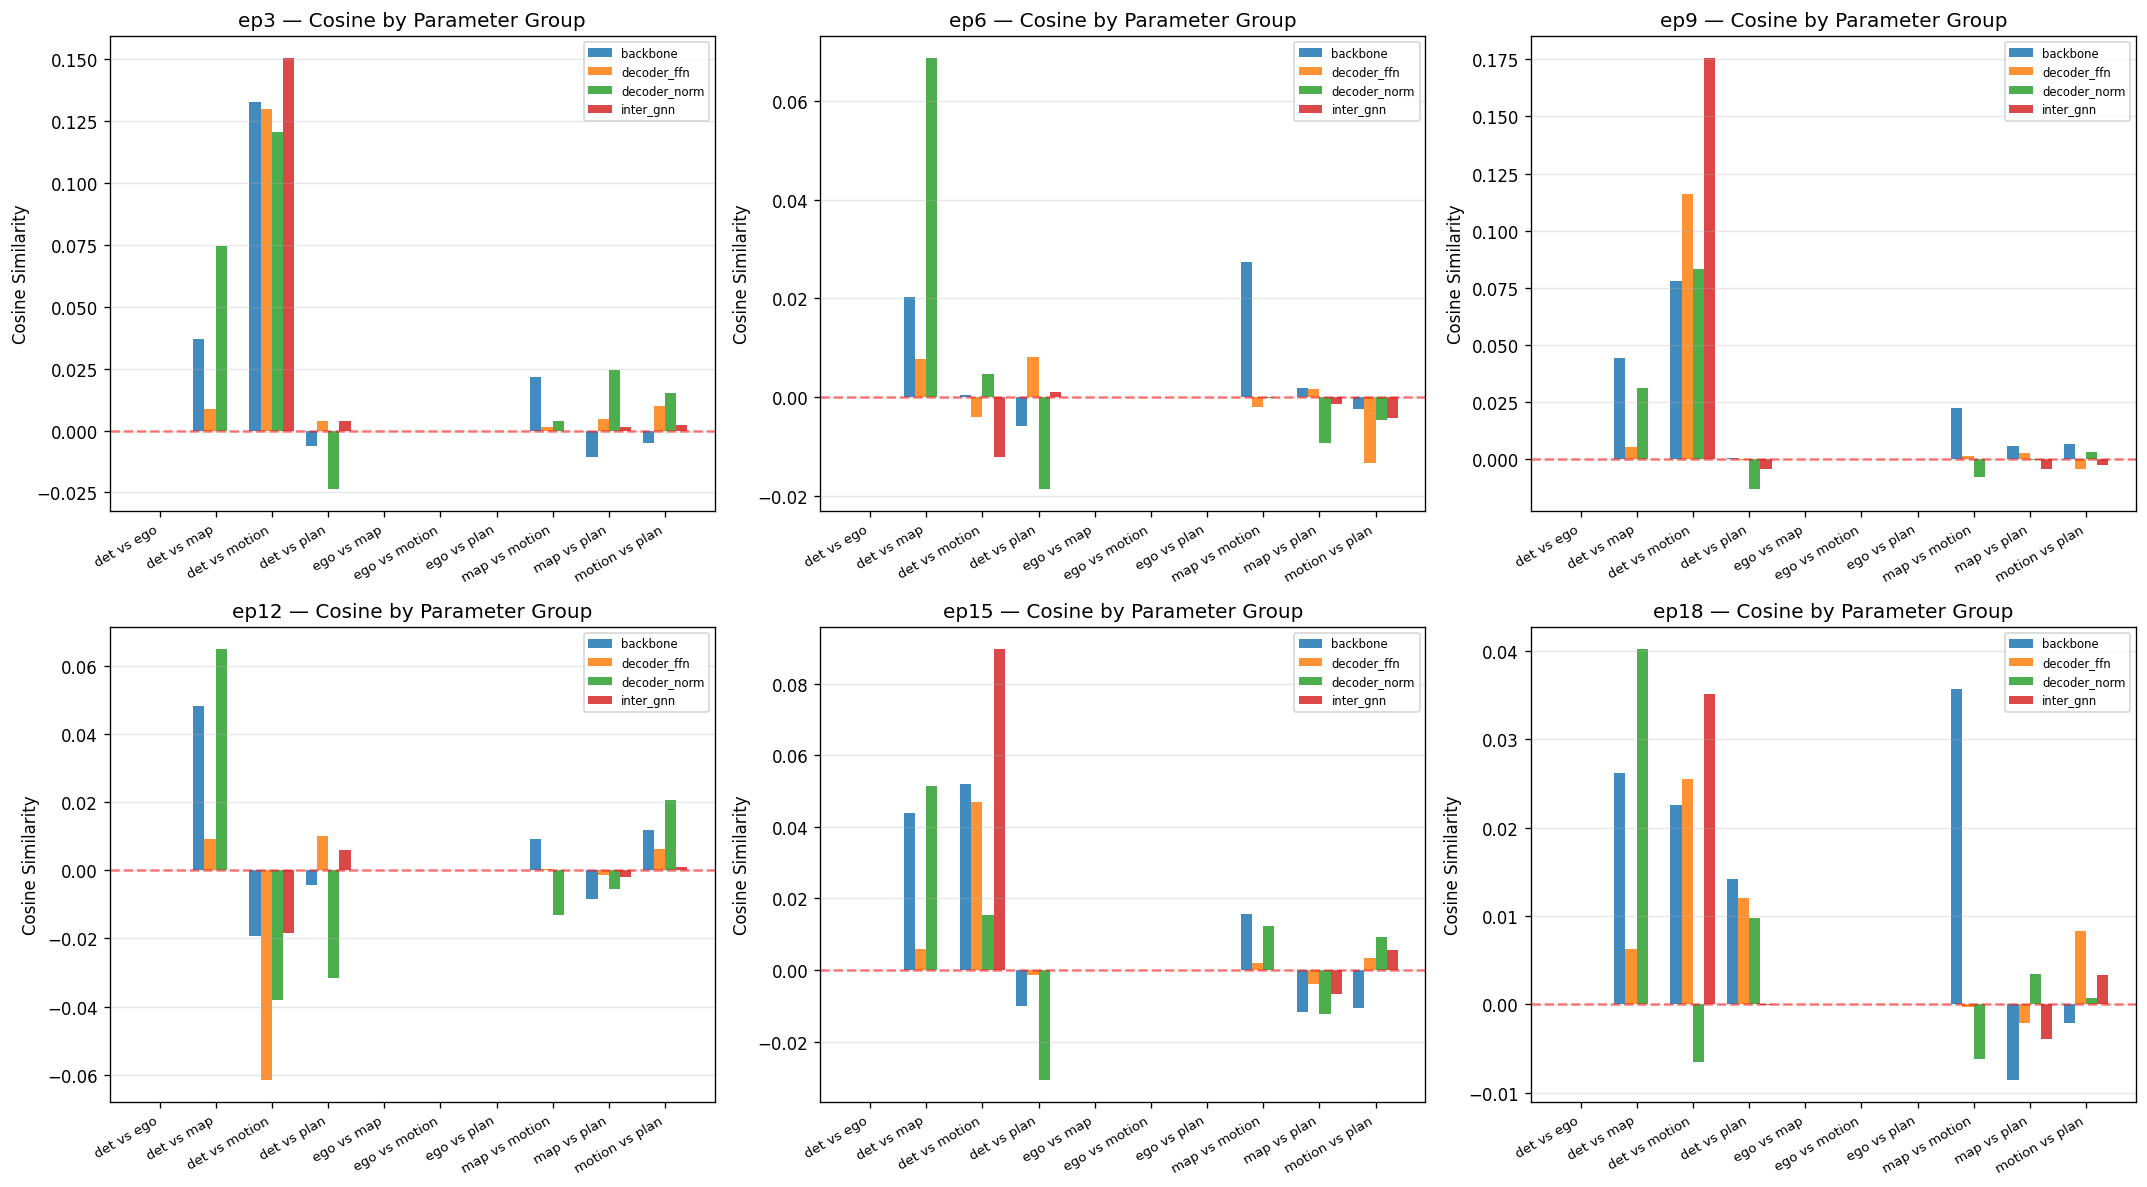

In [13]:
def plot_per_group_cosine(agg_results, epoch_labels):
    groups_to_plot = ['backbone', 'decoder_ffn', 'decoder_norm', 'inter_gnn']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, epoch_label in zip(axes, epoch_labels):
        all_pairs = set()
        for g in groups_to_plot:
            all_pairs.update(agg_results[epoch_label].get(g, {}).keys())
        all_pairs = sorted(all_pairs)
        x = np.arange(len(all_pairs))
        width = 0.8 / len(groups_to_plot)
        for i, g in enumerate(groups_to_plot):
            vals = [agg_results[epoch_label].get(g, {}).get(p, {}).get('cosine_mean', np.nan)
                    for p in all_pairs]
            ax.bar(x + i * width, vals, width, label=g, alpha=0.85)
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.set_xticks(x + width * (len(groups_to_plot) - 1) / 2)
        ax.set_xticklabels([f'{p[0]} vs {p[1]}' for p in all_pairs], rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('Cosine Similarity')
        ax.set_title(f'{epoch_label} — Cosine by Parameter Group')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


plot_per_group_cosine(agg_results, EPOCH_LABELS)

## 12. Batch-level Distribution (Boxplot)

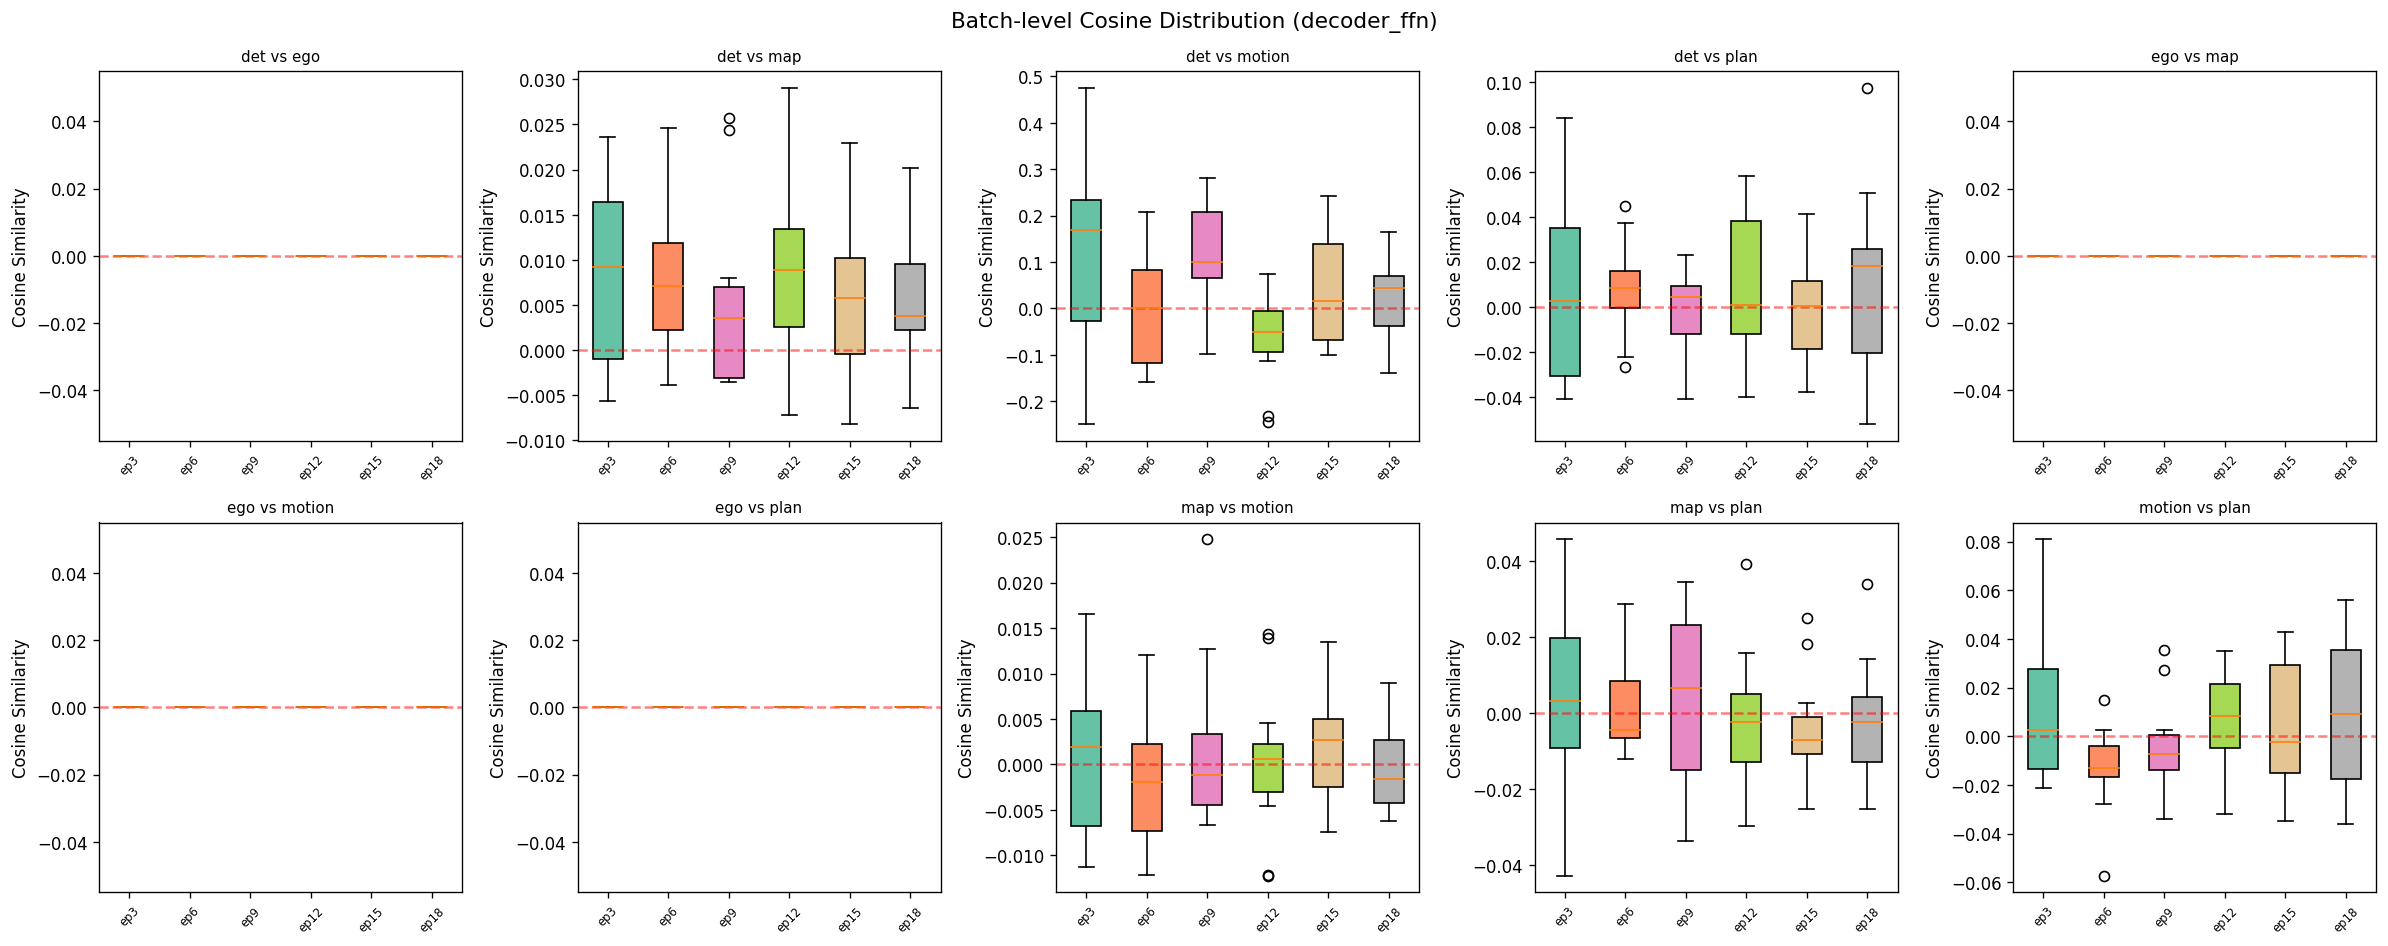

In [14]:
def plot_batch_distribution(agg_results, epoch_labels, group='decoder_ffn'):
    all_pairs = set()
    for name in epoch_labels:
        all_pairs.update(agg_results[name].get(group, {}).keys())
    all_pairs = sorted(all_pairs)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for ax, pair in zip(axes, all_pairs):
        data_to_plot = []
        labels = []
        for name in epoch_labels:
            m = agg_results[name].get(group, {}).get(pair, {})
            if 'cosine_all' in m:
                data_to_plot.append(m['cosine_all'])
                labels.append(name)
        if data_to_plot:
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            colors = plt.cm.Set2(np.linspace(0, 1, len(data_to_plot)))
            for patch, c in zip(bp['boxes'], colors):
                patch.set_facecolor(c)
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.set_title(f'{pair[0]} vs {pair[1]}', fontsize=9)
        ax.set_ylabel('Cosine Similarity')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    # Hide unused axes
    for ax in axes[len(all_pairs):]:
        ax.set_visible(False)
    fig.suptitle(f'Batch-level Cosine Distribution ({group})', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_batch_distribution(agg_results, EPOCH_LABELS, group='decoder_ffn')

## 13. Save Results

In [ ]:
save_data = {}
for epoch_label, agg in agg_results.items():
    save_data[epoch_label] = {}
    for group, pairs in agg.items():
        save_data[epoch_label][group] = {}
        for pair, m in pairs.items():
            key = f'{pair[0]}_vs_{pair[1]}'
            save_data[epoch_label][group][key] = {
                k: float(v) for k, v in m.items()
                if not isinstance(v, np.ndarray)
            }

output_path = 'work_dirs/gradient_analysis_3layer_results.json'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w') as f:
    json.dump(save_data, f, indent=2)
print(f'Saved to {output_path}')

Saved to work_dirs/gradient_analysis_3layer_results.json


: 